C:\Users\tiago\AppData\Local\Temp\ipykernel_17892\3467871233.py:55: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  h, bins, patches = plt.hist(x, 256, [0, 256])


time:  0.0021016597747802734
Numero de simbolos na tabela:  256


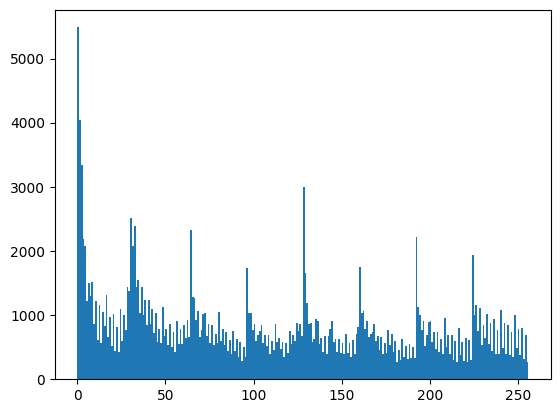

In [40]:
from time import time
from os import path
import numpy as np
import cv2
import matplotlib.pyplot as plt

def gen_huff_table(simbolos, prob_simbolos):
    # 1. Criar a lista de nós inicial (apenas para símbolos com frequência > 0)
    # Cada nó é uma lista: [frequência, símbolo, esquerda, direita] 
    nodes = []
    for i in range(len(simbolos)):
        if prob_simbolos[i] > 0:
            nodes.append([prob_simbolos[i], simbolos[i], None, None])

    if len(nodes) == 0: return {}
    if len(nodes) ==  1:
        return {nodes[0][1]: '0'}

    # 2. Construir a Árvore de Huffman
    while len(nodes) > 1:
        nodes.sort(key=lambda x: x[0])

        # Extrair os dois nós com menores frequências
        esquerda = nodes.pop(0)
        direita = nodes.pop(0)

        # Criar nó pai (soma das frequências, símbolo None, filhos esquerda e direita)  
        novo_no = [esquerda[0] + direita[0], None, esquerda, direita]
        nodes.append(novo_no)   

    # 3. Gerar os códigos binários percorrendo a árvore (Recursividade)
    tabela_huffman = {}
    raiz = nodes[0]
    stack = [[raiz, ""]] # Guarda [nó, código_acumulado]

    while len(stack) > 0:
        no, codigo = stack.pop()

        # Se tem símbolo, é folha
        if no[1] is not None:
            tabela_huffman[no[1]] = codigo
        else:
            #Adiciona filhos à stack (Direita = 1, Esquerda = 0)
            if no[3] is not None:
                stack.append([no[3], codigo + "1"])
            if no[2] is not None:
                stack.append([no[2], codigo + "0"])   
    return tabela_huffman                      


# Ler um dos ficheiros
x = np.fromfile("LenaGray.tif", dtype ="uint8")

# Calcular o histogram
h, bins, patches = plt.hist(x, 256, [0, 256])

# Gerar o codigo de Huffman
to = time()
tabela_codigo = gen_huff_table(np.arange(0, 256), h)
t1 = time()

print("time: ", t1 - to)
print("Numero de simbolos na tabela: ", len(tabela_codigo))


In [41]:
def encode_huff(simbolos, tabela):
    mensagem_codificada = [tabela[s] for s in simbolos]

    return "".join(mensagem_codificada)

# Codificar a mensagem
seq_bit0 = encode_huff(x, tabela_codigo)

In [42]:
def decode_huff(sequencia_bits, tabela):
    root  = {}
    for simbolo, codigo in tabela.items():
        node = root
        for bit in codigo:
            if bit not in node:
                node[bit] = {}
            node = node[bit]
        node['res'] = simbolo

    simbolos_descodificados = []
    node = root
    for bit in sequencia_bits:
        if bit not in node:
            break
        node = node[bit]
        if 'res' in node:
            simbolos_descodificados.append(node['res'])
            node = root

    return np.array(simbolos_descodificados, dtype="uint8")                          

In [43]:
def encode_table(tabela):
    bits_tabela = ""
    num_entradas = len(tabela)

    val_to_bin = 0 if num_entradas == 256 else num_entradas
    bits_tabela += bin(val_to_bin)[2:].zfill(8)

    for simbolo, codigo in tabela.items():
        bits_simbolo = bin(int(simbolo))[2:].zfill(8)
        bits_size = bin(len(codigo))[2:].zfill(8)
        bits_tabela += bits_simbolo + bits_size + codigo
    return bits_tabela    

# Codificar a tabela
seq_bit_tabela = encode_table(tabela_codigo)
seq_bit_total = seq_bit_tabela + seq_bit0

print("Tamanho da tabela (bits):", len(seq_bit_tabela))
print("Tamanho total (tabela + mensagem):", len(seq_bit_total))

Tamanho da tabela (bits): 6212
Tamanho total (tabela + mensagem): 1643322


In [44]:
def write2file(seq_bits, nome_ficheiro):
    padding = (8 - len(seq_bits) % 8) % 8
    seq_bits_ajustada = seq_bits + ("0" * padding)

    bit_array = np.array([int(b) for b in seq_bits_ajustada], dtype=np.uint8)

    byte_array = np.packbits(bit_array)

    with open(nome_ficheiro, "wb") as f:
        f.write(byte_array.tobytes())

    print(f"Ficheiro '{nome_ficheiro}' gravado com sucesso")
    print(f"Tamanho final no disco: {len(byte_array)} bytes.")        

In [45]:
def decode_table(seq_total):
    num_entrada = int(seq_total[:8], 2)
    if num_entrada == 0: num_entrada = 256

    pos = 8
    tabela_recuperada = {}
    for _ in range(num_entrada):
        simbolo = int(seq_total[pos:pos+8], 2)
        pos += 8
        tamanho_codigo = int(seq_total[pos:pos+8], 2)
        pos+=8
        codigo = seq_total[pos:pos+tamanho_codigo]
        pos+=tamanho_codigo
        tabela_recuperada[simbolo] = codigo
    return tabela_recuperada, seq_total[pos:]    

In [46]:
def read_file(nome_ficheiro):
    with open(nome_ficheiro, "rb") as f:
        conteudo_bytes = f.read()

    bit_array = np.unpackbits(np.frombuffer(conteudo_bytes,  dtype=np.uint8))
    seq_total = "".join(bit_array.astype(str))

    tabela_recuperada, bits_mensagem = decode_table(seq_total)

    return tabela_recuperada, bits_mensagem    

In [47]:
def calcular_estatisticas(h, tabela_codigo):
    prob = h[h > 0]/ np.sum(h)

    entropia = -np.sum(prob * np.log2(prob))

    comp_medio = 0
    for simbolo, codigo in tabela_codigo.items():
        p_i = h[simbolo]/ np.sum(h)
        comp_medio += p_i * len(codigo)

    eficiencia = (entropia / comp_medio) * 100
    return entropia, comp_medio, eficiencia    

In [48]:
lista_ficheiros = ["LenaGray.tif", "LenaColor.tif", "DecUniversalDH.txt", "HenryMancini-PinkPanther30s.mp3"]

for nome_f in lista_ficheiros:
    if not path.exists(nome_f):
        print(f"\nFicheiro {nome_f} não encontrado. Próximo...")
        continue
    
    print(f"\n---Analisando: {nome_f} ---")

    dados_originais = np.fromfile(nome_f, dtype="uint8")

    # a) gerar tabela e medir tempo
    h, _ = np.histogram(dados_originais, bins=256, range=(0, 256))
    t0 = time()
    tabela = gen_huff_table(np.arange(256), h)
    t1 = time()
    print(f"Tempo Geração Tabela: {t1 - t0:.6f}s")

    # b) estatisticas
    Entropia, Comprimento, Eficiencia = calcular_estatisticas(h, tabela)
    print(f"Entropia:  {Entropia:.4f} bits/simbolo")
    print(f"Nº médio de bits (Comprimento): {Comprimento:.4f} bits/simbolo")
    print(f"Eficiência: {Eficiencia:.2f}%")

    # c) codificar mensagem
    t_enc_0 = time()
    seq_bits_msg = encode_huff(dados_originais, tabela)
    t_enc_1 = time()
    print(f"Tempo Codificação: {t_enc_1 - t_enc_0:.6f}s")

    # d) Gravar Ficheiro
    seq_bits_tab = encode_table(tabela)
    stream_total = seq_bits_tab + seq_bits_msg
    nome_comp = nome_f + ".huff"
    write2file(stream_total, nome_comp)

    size_ini = path.getsize(nome_f)
    size_end = path.getsize(nome_comp)
    print(f"Taxa de Compressão: {size_ini / size_end:.2f}:1")

    # e) e f) ler e descodificar
    t_dec_0 = time()
    tab_lida, msg_lida = read_file(nome_comp)
    dados_recuperados  = decode_huff(msg_lida, tab_lida)
    dados_recuperados = dados_recuperados[:len(dados_originais)]
    t_dec_1 = time()
    print(f"Tempo de Descodificação: {t_dec_1 - t_dec_0:.6f}s")

    # g) Verificação de Erro  Nulo
    igual = np.array_equal(dados_originais, dados_recuperados)
    print(f"Recuperação Perfeita (Erro Nulo): {igual}")


---Analisando: LenaGray.tif ---
Tempo Geração Tabela: 0.003145s
Entropia:  7.7614 bits/simbolo
Nº médio de bits (Comprimento): 7.7912 bits/simbolo
Eficiência: 99.62%
Tempo Codificação: 0.020844s
Ficheiro 'LenaGray.tif.huff' gravado com sucesso
Tamanho final no disco: 205416 bytes.
Taxa de Compressão: 1.02:1
Tempo de Descodificação: 0.555625s
Recuperação Perfeita (Erro Nulo): True

---Analisando: LenaColor.tif ---
Tempo Geração Tabela: 0.002007s
Entropia:  7.7514 bits/simbolo
Nº médio de bits (Comprimento): 7.7818 bits/simbolo
Eficiência: 99.61%
Tempo Codificação: 0.074158s
Ficheiro 'LenaColor.tif.huff' gravado com sucesso
Tamanho final no disco: 765903 bytes.
Taxa de Compressão: 1.03:1
Tempo de Descodificação: 2.192908s
Recuperação Perfeita (Erro Nulo): True

---Analisando: DecUniversalDH.txt ---
Tempo Geração Tabela: 0.000000s
Entropia:  4.4170 bits/simbolo
Nº médio de bits (Comprimento): 4.4519 bits/simbolo
Eficiência: 99.22%
Tempo Codificação: 0.001003s
Ficheiro 'DecUniversalDH.txt